---
#  Clase 07a: Imágenes Sentinel-2: Extracción de muestras
---

En esta clase utilizaremos una escena satelital Sentinel-2 correspondiente a la zona del dique Roggero, Buenos Aires, sobre la cual construiremos muestras espectrales para utilizar en las clasificaciones de la Clase 07b. Partiremos del mismo archivo GeoTiff trabajado en la Notebook anterior y de los vectores con clases temáticas que hayas marcado sobre los mapas.  

### Objetivos de la notebook:

- [x] Utilizar un archivo vectorial externo para construir muestras espectrales a partir de la imagen.
- [X] Construir o adaptar muestras propias y generar un archivo final para utilizar en las clasificaciones de la Clase 07b. 

### Datos con los que trabajaremos en esta Notebook:

- Escena Sentinel-2 del dique Roggero ya preprocesada disponible en **data/S2_20181006.tif**
- Archivo vectorial con muestras de clases temáticas de ejemplo: **data/rois_dique.geojson** (enlace de descarga [aquí](https://drive.google.com/file/d/1QmboZ50GRfrr9_BOXkBN9aNwXFPoUNnD/view?usp=sharing))

### Tile T21HUB y Zona del Dique Roggero: 
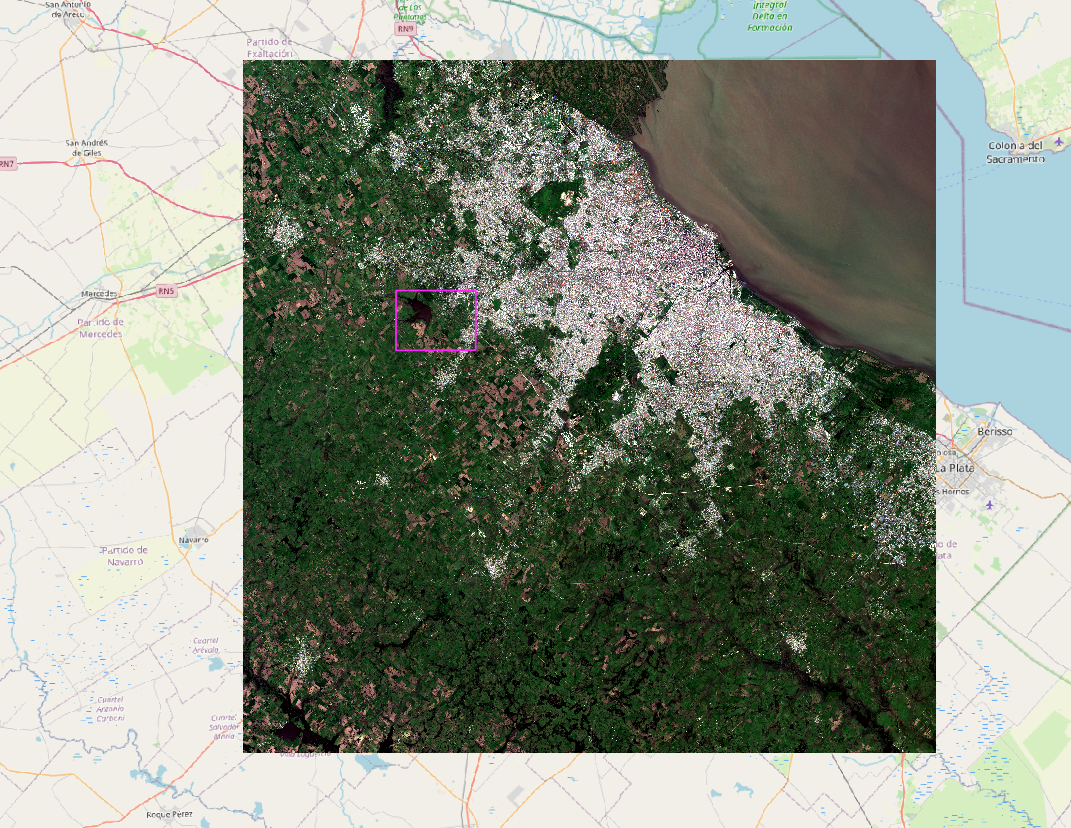

## 1. Extracción de muestras de interés

A continuación vamos a leer un vector que fue digitalizado sobre distintas coberturas del suelo en la zona del dique Roggero

```python
import geopandas as gpd

rois_vec = gpd.read_file('data/rois_dique.geojson')
rois_vec.head(10)
```

In [1]:
import geopandas as gpd

rois_path = 'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/muestras_drog.gpkg'
rois_vec = gpd.read_file(rois_path)
rois_vec.head(10)

,id,clase,geometry
0,1.0,agua,"MULTIPOLYGON (((-58.88273 -34.67582, -58.88276..."
1,2.0,agua,"MULTIPOLYGON (((-58.88775 -34.69571, -58.88772..."
2,3.0,agua,"MULTIPOLYGON (((-58.86504 -34.69719, -58.865 -..."
3,4.0,agua,"MULTIPOLYGON (((-58.82888 -34.68435, -58.82888..."
4,5.0,agua,"MULTIPOLYGON (((-58.78411 -34.66777, -58.7841 ..."
5,6.0,agua,"MULTIPOLYGON (((-58.91231 -34.69817, -58.9123 ..."
6,7.0,agua,"MULTIPOLYGON (((-58.8658 -34.68379, -58.86576 ..."
7,NaN,suel_desn,"MULTIPOLYGON (((-58.87845 -34.70994, -58.87841..."
8,NaN,suel_desn,"MULTIPOLYGON (((-58.91226 -34.6777, -58.91223 ..."
9,NaN,suel_desn,"MULTIPOLYGON (((-58.88029 -34.72793, -58.88025..."


Visualicemos en conjunto los vectores coloreados por clase, con la imagen de fondo, aplicando lo aprendido en la Clase 04:

```python
import rasterio 
from rasterio.plot import plotting_extent
import funciones as fn
import matplotlib.pyplot as plt

# Leemos la imagen, calculamos su extent para el ploteo
raster_fn = 'output/S2_20181006.tif'

with rasterio.open(raster_fn) as src:
    img = src.read()
    extent = plotting_extent(src) 

# Escalamos la imagen para visualizar
imagen_escalada = fn.scale_multiband(img, p=2)

# Ploteamos la imagen con los vectores superpuestos
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(imagen_escalada[[2,1,0]].transpose(1,2,0), extent = extent)
rois_vec.plot(ax=ax, column='clase', legend = True)
rois_vec.boundary.plot(ax=ax, color='orangered')
ax.ticklabel_format(style='plain')

plt.show()
```

In [9]:
src.crs

CRS.from_wkt('PROJCS["WGS 84 / UTM zone 21S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-57],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32721"]]')

1181.0 2360.0
1281.0 2612.0
1227.0 2762.0
1306.0 5528.0
1079.0 4588.0
1068.0 3971.0


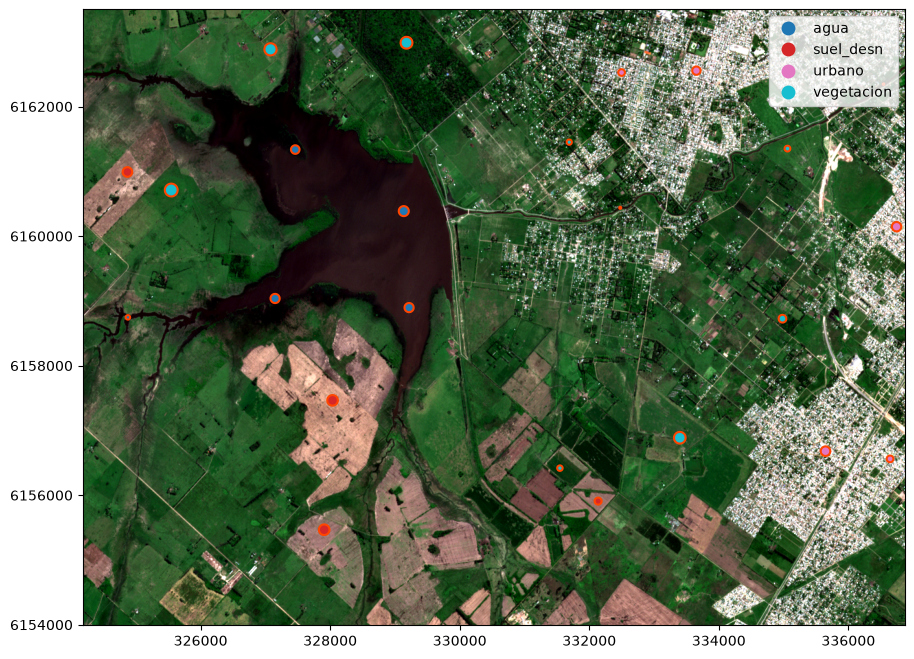

In [17]:
import rasterio 
from rasterio.plot import plotting_extent
import funciones as fn
import matplotlib.pyplot as plt

# Leemos la imagen, calculamos su extent para el ploteo
raster_fn = 'output/S2_20181006.tif'

with rasterio.open(raster_fn) as src:
    img = src.read()
    extent = plotting_extent(src) 

# Escalamos la imagen para visualizar
imagen_escalada = fn.scale_multiband(img, p=2)

# Reproyecto el archivo vectorial
rois_vec = rois_vec.to_crs(epsg=32721)

# Ploteamos la imagen con los vectores superpuestos
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(imagen_escalada[[2,1,0]].transpose(1,2,0), extent = extent)
rois_vec.plot(ax=ax, column='clase', legend = True)
rois_vec.boundary.plot(ax=ax, color='orangered')
ax.ticklabel_format(style='plain')

plt.show()

### 1.1. Uso de `mask` para extraer valores

Como vimos en notebooks anteriores, es posible generar recortes a partir de nuestros polígonos haciendo uso del módulo [rasterio.mask](https://rasterio.readthedocs.io/en/latest/api/rasterio.mask.html). Veamos un ejemplo con nuestros datos:

```python
from rasterio.mask import mask

# Aquí extraemos la geometría del primer ROI
roi0 = rois_vec['geometry'][0]

# Utilicemos el ROI anterior para extraer los valores de la imagen
with rasterio.open(raster_fn) as src:
     out_image, out_transform = mask(src, [roi0], crop=True)

out_image_esc = fn.scale_multiband(out_image, p =2, nodata = 0)
# Grafiquemos nuestro subset
fig, ax = plt.subplots()
ax.imshow(out_image_esc[[2,1,0]].transpose(1,2,0))
plt.show()
```

0.0 1235.6399999999999
0.0 1391.1
0.0 1291.0
0.0 2102.7199999999993
0.0 1334.46
0.0 1201.82


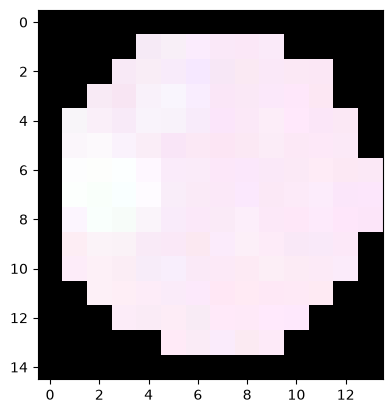

In [18]:
from rasterio.mask import mask

# Aquí extraemos la geometría del primer ROI
roi0 = rois_vec['geometry'][0]

# Utilicemos el ROI anterior para extraer los valores de la imagen
with rasterio.open(raster_fn) as src:
     out_image, out_transform = mask(src, [roi0], crop=True)

out_image_esc = fn.scale_multiband(out_image, p =2, nodata = 0)
# Grafiquemos nuestro subset
fig, ax = plt.subplots()
ax.imshow(out_image_esc[[2,1,0]].transpose(1,2,0))
plt.show()

Podemos aprovechar al `mask` para generar una base de muestras _etiquetadas_ por clase. Para entender mejor nuestros datos y usarlos en una clasificación, es necesario asociar la información de nuestras imágenes a su respectiva etiqueta, la cual puede provenir por ejemplo de información relevada en campo o interpretación visual sobre las mismas. Para realizar esto, vamos a construir una tabla que contendrá como _features_ o características la información espectral proveniente de las bandas de nuestras imagen y, como _labels_ o etiquetas, el valor correspondiente a la clases de cada polígono ROI. Iniciemos con una sola clase:

Leamos nuestro vector y recortemos a un polígono

```python
# Definimos un valor fuera de nuestro rango válido para los datos no válidos
nodata = 65535

# Cargamos nuestros polígonos y nos quedamos con uno de los elementos
clase, geom = rois_vec.loc[0, ['clase', 'geometry']].to_list()

# Cargamos la imagen y la recortamos a nuestro polígono
with rasterio.open(raster_fn) as src:
    clip, _transform = mask(src, [geom], crop=True, nodata=nodata)
```

In [19]:
# Definimos un valor fuera de nuestro rango válido para los datos no válidos
nodata = 65535

# Cargamos nuestros polígonos y nos quedamos con uno de los elementos
clase, geom = rois_vec.loc[0, ['clase', 'geometry']].to_list()

# Cargamos la imagen y la recortamos a nuestro polígono
with rasterio.open(raster_fn) as src:
    clip, _transform = mask(src, [geom], crop=True, nodata=nodata)

En nuestra celda anterior, `clip` es un arreglo de tres dimensiones con la estructura **(bandas, filas, columnas)**. Es decir, cada píxel posee **6 valores espectrales**, uno por cada banda.

Para entrenar un clasificador, debemos convertir este arreglo tridimensional en una **tabla plana**, donde **cada fila representa un píxel** y **cada columna corresponde a una banda**.

| Píxel | B02 | B03 | B04 | B08 | B11 | B12 |
|:-----:|----:|----:|----:|----:|----:|----:|
| 1 | 135 | 148 | 172 | 201 | 98 | 76 |
| 2 | 132 | 145 | 169 | 198 | 95 | 73 |
| 3 | 141 | 152 | 180 | 214 | 101 | 81 |
| ⋮ | ⋮ | ⋮ | ⋮ | ⋮ | ⋮ | ⋮ |
| N | 127 | 139 | 164 | 190 | 92 | 70 |

De esta manera, cada fila constituye una **muestra** (un píxel) y las columnas contienen las **variables predictoras** que utilizará el algoritmo de clasificación. Veamos como hacerlo con las herramientas que nos ofrece `Numpy`

```python
import numpy as np 

d, x, y = clip.shape
D = clip.reshape([d, x*y]).T  # rompemos la estructura espacial, pero no espectral
DX = D[np.all(D != nodata, axis=1)]  # Nos quedamos con los valores útiles
DY = np.repeat(clase, DX.shape[0])  # Generamos un array con la etiqueta de la clase
```

In [20]:
import numpy as np 

d, x, y = clip.shape
D = clip.reshape([d, x*y]).T  # rompemos la estructura espacial, pero no espectral
DX = D[np.all(D != nodata, axis=1)]  # Nos quedamos con los valores útiles
DY = np.repeat(clase, DX.shape[0])  # Generamos un array con la etiqueta de la clase

Veamos algunos datos etiquetados. Para ello, podemos utilizar las estructura que nos brinda `Pandas` definiendo un `DataFrame`:

```python
import pandas as pd

muestras_agua = pd.DataFrame(DX, columns=['B02', 'B03', 'B04', 'B08', 'B11', 'B12'])
muestras_agua['Clase'] = DY
muestras_agua.head(10)
```

In [21]:
import pandas as pd

muestras_agua = pd.DataFrame(DX, columns=['B02', 'B03', 'B04', 'B08', 'B11', 'B12'])
muestras_agua['Clase'] = DY
muestras_agua.head(10)

,B02,B03,B04,B08,B11,B12,Clase
0,1194,1278,1250,1606,1189,1119,agua
1,1200,1306,1256,1694,1203,1125,agua
2,1226,1288,1275,1680,1175,1110,agua
3,1205,1270,1268,1438,1130,1091,agua
4,1198,1262,1273,1336,1099,1085,agua
5,1207,1280,1270,1382,1087,1086,agua
6,1195,1273,1256,1560,1162,1110,agua
7,1195,1297,1261,1584,1177,1118,agua
8,1212,1282,1258,1574,1186,1120,agua
9,1236,1270,1248,1621,1155,1105,agua


Vamos a extender lo anterior a todas las clases, para lo que asumiremos que ya cargamos nuestros ROIs y definimos nuestro valor _nodata_. En este caso tendremos previmente que generar un array para ir concatenando los datos contenidos en cada ROI, así como sus valores de clase. Además, vamos a generar un listado con las etiquetas posibles:

```python
# primero defino cantidad de atributos = cantidad de bandas en el raster
with rasterio.open(raster_fn) as src:
    d = src.count 

# Clases de los ROIs
clases = list(set(rois_vec['clase']))
clases.sort()
```

In [22]:
# primero defino cantidad de atributos = cantidad de bandas en el raster
with rasterio.open(raster_fn) as src:
    d = src.count 

# Clases de los ROIs
clases = list(set(rois_vec['clase']))
clases.sort()

Creamos los vectores para almacenar nuestra información de datos y etiquetas

```python
#d corresponde a la cantidad de bandas, ya lo tenemos definido de antes

X = np.empty((0, d), dtype=np.float32)  # array vacío para almacenar valores espectrales
Y = np.empty(0, dtype=int)              # array vacío para almacenar etiquetas
```

In [23]:
#d corresponde a la cantidad de bandas, ya lo tenemos definido de antes

X = np.empty((0, d), dtype=np.float32)  # array vacío para almacenar valores espectrales
Y = np.empty(0, dtype=int)              # array vacío para almacenar etiquetas

Con el raster abierto, iteramos sobre los polígonos y extraemos para cada uno la información que nos interesa, en cada iteración almacenamos la información extraida con su respectiva etiqueta:

```python
with rasterio.open(raster_fn) as src:
    for index, row in rois_vec.iterrows():
        clase, geom = row[['clase', 'geometry']].to_list()
        clip, _transform = mask(src, [geom], crop=True, nodata=nodata)
        d, x, y = clip.shape
        D = clip.reshape([d, x*y]).T  # Rompemos la estructura espacial, pero no espectral
        DX = D[np.all(D != nodata, axis=1)]  # Nos quedamos con los valores útiles
        DY = np.repeat(clase, DX.shape[0])  # Generamos un array con la etiqueta de la clase
        X = np.concatenate((X, DX))  # Concatenamos nuestros datos espectrales
        Y = np.concatenate((Y, DY))  # Concatenamos las etiquetas de la clase
```

In [24]:
with rasterio.open(raster_fn) as src:
    for index, row in rois_vec.iterrows():
        clase, geom = row[['clase', 'geometry']].to_list()
        clip, _transform = mask(src, [geom], crop=True, nodata=nodata)
        d, x, y = clip.shape
        D = clip.reshape([d, x*y]).T  # Rompemos la estructura espacial, pero no espectral
        DX = D[np.all(D != nodata, axis=1)]  # Nos quedamos con los valores útiles
        DY = np.repeat(clase, DX.shape[0])  # Generamos un array con la etiqueta de la clase
        X = np.concatenate((X, DX))  # Concatenamos nuestros datos espectrales
        Y = np.concatenate((Y, DY))  # Concatenamos las etiquetas de la clase

El array X tiene una fila por cada pixel (con sus datos espectrales), mientras que Y tiene un elemento por cada pixel indicando la clase correspondiente. Veamos una muestra de algunos datos etiquetados:

```python
muestras = pd.DataFrame(X, columns=['B02', 'B03', 'B04', 'B08', 'B11', 'B12'])

muestras['Clase'] = Y

muestras.sample(10)
```

In [25]:
muestras = pd.DataFrame(X, columns=['B02', 'B03', 'B04', 'B08', 'B11', 'B12'])

muestras['Clase'] = Y

muestras.sample(10)

,B02,B03,B04,B08,B11,B12,Clase
1995,2376.0,2572.0,2602.0,2910.0,4121.0,4002.0,urbano
1032,1650.0,1925.0,2150.0,2974.0,4420.0,3906.0,suel_desn
1551,2592.0,3128.0,3166.0,4946.0,4274.0,3714.0,urbano
289,1225.0,1274.0,1343.0,1232.0,1102.0,1091.0,agua
2524,1400.0,1792.0,1567.0,4616.0,3699.0,2535.0,vegetacion
2865,1232.0,1549.0,1290.0,4144.0,2606.0,1869.0,vegetacion
1492,2076.0,3088.0,2790.0,4085.0,4956.0,5043.0,urbano
3040,1301.0,1538.0,1433.0,2714.0,2787.0,2102.0,vegetacion
882,1791.0,2110.0,2472.0,3490.0,4695.0,3881.0,suel_desn
630,1276.0,1356.0,1447.0,1325.0,1074.0,1074.0,agua


Este `Dataframe` se puede guardar como archivo CSV para su posterior uso:

```python
muestras.to_csv('output/Clase07a_muestras_ejemplo.csv')
```

In [26]:
muestras.to_csv('output/Clase07a_muestras_ejemplo.csv')

### 1.2. Visualizar las firmas espectrales

Con las muestras ya extraídas a un `Dataframe`, podemos graficar sus patrones espectrales, al igual que hicimos con los _clusters_ de la Clase 06. La celda de abajo calcula los valores medios para cada clase con sus correspondientes desvíos, y los usa plara graficar sobre una misma figura:

```python
# Bandas a utilizar
bandas = ['B02', 'B03', 'B04', 'B08', 'B11', 'B12']

# Longitudes de onda centrales aproximadas, en micrómetros
longitudes_onda = [0.490, 0.560, 0.665, 0.842, 1.610, 2.190]

fig, ax = plt.subplots(figsize=(15, 10))

for clase, grupo in muestras.groupby('Clase'):

    datos_clase = grupo[bandas] / 10000 # Dividimos por 10000 para que los valores queden expresados entre 0 y 1

    media_clase = datos_clase.mean(axis=0).to_numpy()
    std_clase = datos_clase.std(axis=0).to_numpy()

    ax.plot(longitudes_onda, media_clase, marker='o', label=clase)

    ax.fill_between(longitudes_onda, media_clase - std_clase, media_clase + std_clase, alpha=0.1)

ax.set_xlabel('Longitud de onda (µm)')
ax.set_ylabel('Valor espectral')
ax.set_title('Firmas espectrales de las clases')

ax.set_xticks(longitudes_onda)
ax.set_xticklabels(['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2'])

ax.legend(title='Clase')
ax.grid(alpha=0.3)

plt.show()
```

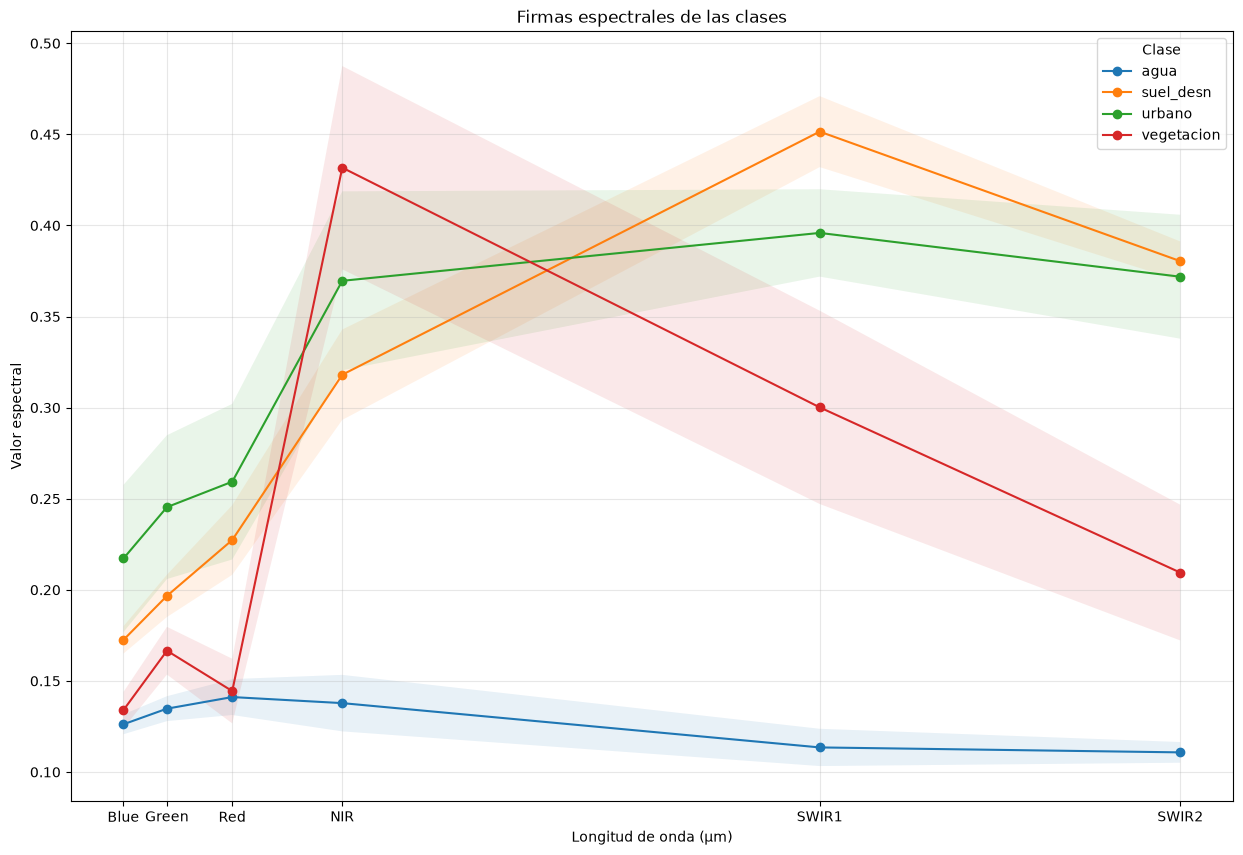

In [27]:
# Bandas a utilizar
bandas = ['B02', 'B03', 'B04', 'B08', 'B11', 'B12']

# Longitudes de onda centrales aproximadas, en micrómetros
longitudes_onda = [0.490, 0.560, 0.665, 0.842, 1.610, 2.190]

fig, ax = plt.subplots(figsize=(15, 10))

for clase, grupo in muestras.groupby('Clase'):

    datos_clase = grupo[bandas] / 10000 # Dividimos por 10000 para que los valores queden expresados entre 0 y 1

    media_clase = datos_clase.mean(axis=0).to_numpy()
    std_clase = datos_clase.std(axis=0).to_numpy()

    ax.plot(longitudes_onda, media_clase, marker='o', label=clase)

    ax.fill_between(longitudes_onda, media_clase - std_clase, media_clase + std_clase, alpha=0.1)

ax.set_xlabel('Longitud de onda (µm)')
ax.set_ylabel('Valor espectral')
ax.set_title('Firmas espectrales de las clases')

ax.set_xticks(longitudes_onda)
ax.set_xticklabels(['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2'])

ax.legend(title='Clase')
ax.grid(alpha=0.3)

plt.show()

Otra herramienta de gran utilidad son los gŕaficos de dispersión de a pares de bandas. Para ello, la librería `Seaborn` nos simplifica el trabajo usando la herramienta `pairplot`, tal como lo hicimos en la Clase 06:

```python
import seaborn as sns

colores = {
    'agua': '#1f77b4',      # azul
    'vegetacion': '#228B22',    # verde oscuro
    'urbano': '#7f7f7f',    # gris
    'suel_desn': '#d62728',     # rojo
}

columnas = ['B02', 'B03', 'B04', 'B08', 'B11', 'B12', 'Clase']

plt.figure()
sns.pairplot(muestras[columnas],hue='Clase', palette = colores)
plt.show()
```

<Figure size 640x480 with 0 Axes>

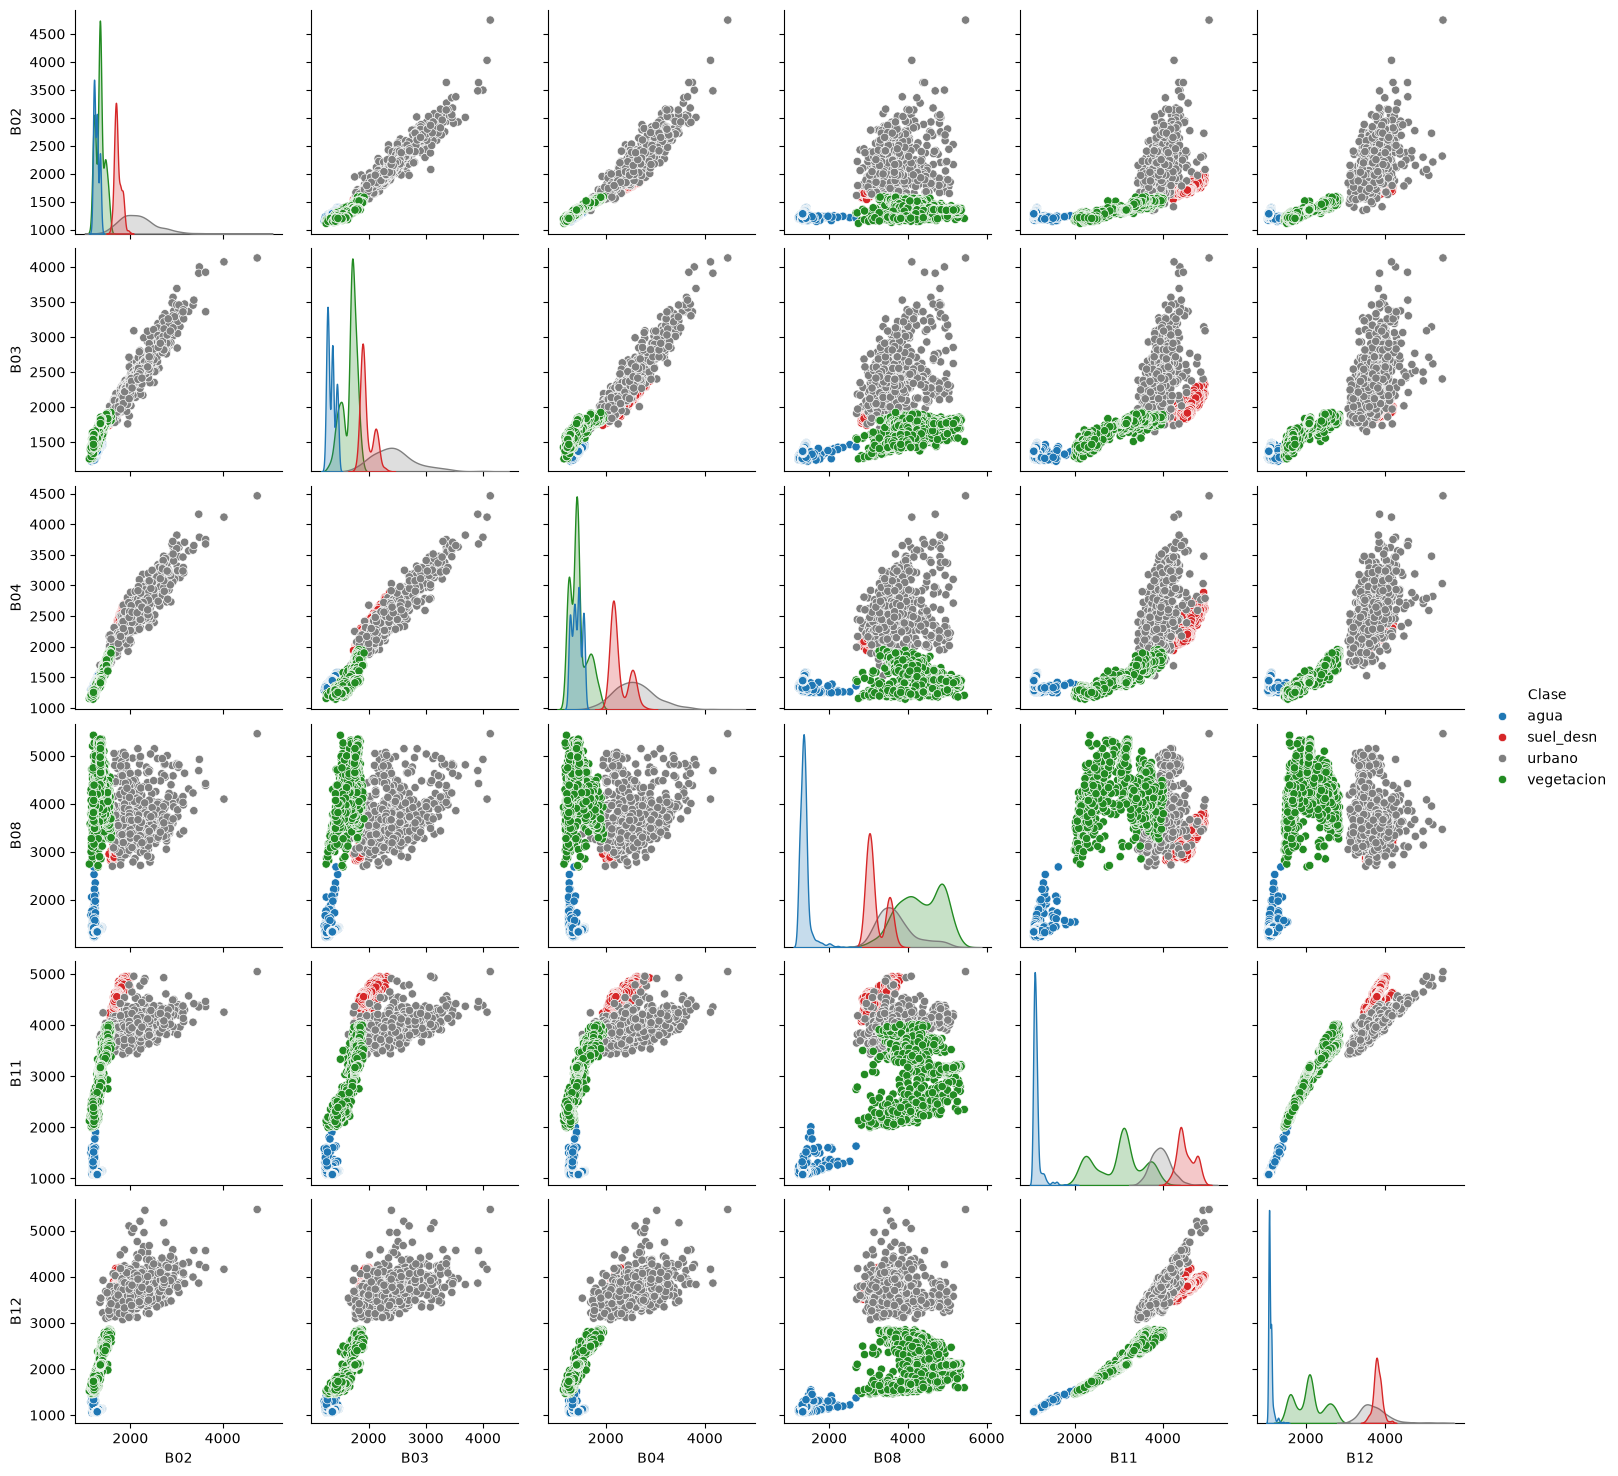

In [29]:
import seaborn as sns

colores = {
    'agua': '#1f77b4',      # azul
    'vegetacion': '#228B22',    # verde oscuro
    'urbano': '#7f7f7f',    # gris
    'suel_desn': '#d62728',     # rojo
}

columnas = ['B02', 'B03', 'B04', 'B08', 'B11', 'B12', 'Clase']

plt.figure()
sns.pairplot(muestras[columnas],hue='Clase', palette = colores)
plt.show()

<h3 style="color:red;">Ejercicio - Entregable!</h3>

Tu tarea ahora va a ser modificar o crear por fuera de Python tu propio archivo vectorial de muestras (el que tenés de la clase anterior, `muestras_Clase06.gpkg`), y repetir los pasos de la sección 2 para extraer un `DataFrame` y analizar cómo se comportan espectralmente. Podés trabajar con las mismas definiciones de clases , o agrupar / dividir en nuevas en función de cómo veas la separabilidad entre las mismas. Una vez que estés conforme, guardá tu `Dataframe` de muestras como archivo CSV, respetando la estructura de columnas que usamos en la sección anterior. 

De manera resumida, los pasos serían:

- Actualizar / crear archivo vectorial propio de muestras (en QGIS o un programa similar). Guardarlos en formato vectorial
- Leer los vectores en esta Notebook con Geopandas
- Extraer los valores de muestras a un `DataFrame` (*)
- Visualizar las firmas espectrales y/0 los gráficos de separabilidad.
- Guardar el `Dataframe` final como archivo CSV para usar en la Clase 07b. Nombralo como `muestras_Clase07.csv`

El objetivo de este ejercicio es que luego de haber tomado una primera versión de las muestras en la clase 06, y pensando ahora en un escenario de aprendizaje supervisado, armes tu propia base de datos para trabajar con los clasificadores.

(*) Para agilizar la extracción de muestras a partir de los vectores, dejamos sistematizada una función. Agregala a tu archivo `funciones.py`:

```python
def extraer_muestras(raster_fn, rois_vec, columna = 'clase', bandas = ['B02', 'B03', 'B04', 'B08', 'B11', 'B12']):
    
    with rasterio.open(raster_fn) as src:
        d = src.count
        X = np.empty((0, d), dtype=np.float32)  # array vacío para almacenar valores espectrales
        Y = np.empty(0, dtype=int)              # array vacío para almacenar etiquetas
        
        for index, row in rois_vec.iterrows():
            clase, geom = row[[columna, 'geometry']].to_list()
            clip, _transform = mask(src, [geom], crop=True, nodata=nodata)
            d, x, y = clip.shape
            D = clip.reshape([d, x*y]).T  # Rompemos la estructura espacial, pero no espectral
            DX = D[np.all(D != nodata, axis=1)]  # Nos quedamos con los valores útiles
            DY = np.repeat(clase, DX.shape[0])  # Generamos un array con la etiqueta de la clase
            X = np.concatenate((X, DX))  # Concatenamos nuestros datos espectrales
            Y = np.concatenate((Y, DY))  # Concatenamos las etiquetas de la clase
            
    muestras = pd.DataFrame(X, columns= bandas)
    muestras['Clase'] = Y

    return muestras
```

In [34]:
import rasterio
import numpy as np
from rasterio.mask import mask
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
def extraer_muestras(raster_fn, rois_vec, nodata = 65535, columna = 'clase', bandas = ['B02', 'B03', 'B04', 'B08', 'B11', 'B12']):
    
    with rasterio.open(raster_fn) as src:
        d = src.count
        X = np.empty((0, d), dtype=np.float32)  # array vacío para almacenar valores espectrales
        Y = np.empty(0, dtype=int)              # array vacío para almacenar etiquetas

        rois_vec = rois_vec.to_crs(epsg=src.crs.to_epsg())
        
        for index, row in rois_vec.iterrows():
            clase, geom = row[[columna, 'geometry']].to_list()
            clip, _transform = mask(src, [geom], crop=True, nodata=nodata)
            d, x, y = clip.shape
            D = clip.reshape([d, x*y]).T  # Rompemos la estructura espacial, pero no espectral
            DX = D[np.all(D != nodata, axis=1)]  # Nos quedamos con los valores útiles
            DY = np.repeat(clase, DX.shape[0])  # Generamos un array con la etiqueta de la clase
            X = np.concatenate((X, DX))  # Concatenamos nuestros datos espectrales
            Y = np.concatenate((Y, DY))  # Concatenamos las etiquetas de la clase
            
    muestras = pd.DataFrame(X, columns= bandas)
    muestras['Clase'] = Y

    return muestras

In [1]:
import geopandas as gpd

rois_path = 'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/muestras_drog.gpkg'
rois_vec = gpd.read_file(rois_path)
rois_vec.head(10)

,id,clase,geometry
0,1.0,agua,"MULTIPOLYGON (((-58.88273 -34.67582, -58.88276..."
1,2.0,agua,"MULTIPOLYGON (((-58.88775 -34.69571, -58.88772..."
2,3.0,agua,"MULTIPOLYGON (((-58.86504 -34.69719, -58.865 -..."
3,4.0,agua,"MULTIPOLYGON (((-58.82888 -34.68435, -58.82888..."
4,5.0,agua,"MULTIPOLYGON (((-58.78411 -34.66777, -58.7841 ..."
5,6.0,agua,"MULTIPOLYGON (((-58.91231 -34.69817, -58.9123 ..."
6,7.0,agua,"MULTIPOLYGON (((-58.8658 -34.68379, -58.86576 ..."
7,NaN,suel_desn,"MULTIPOLYGON (((-58.87845 -34.70994, -58.87841..."
8,NaN,suel_desn,"MULTIPOLYGON (((-58.91226 -34.6777, -58.91223 ..."
9,NaN,suel_desn,"MULTIPOLYGON (((-58.88029 -34.72793, -58.88025..."


In [2]:
list_paths = ['https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/output/S2_20181006_B02_B03_B04_B08_B11.tif',
              'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/output/S2_20181006_B02_B03_B08_B11.tif',
              'https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/practicos/output/S2_20181006_B02_B03_B08_B11_B12.tif']

list_bands = [['B02', 'B03','B04', 'B08', 'B11'],
              ['B02', 'B03', 'B08', 'B11'],
              ['B02', 'B03', 'B08', 'B11', 'B12']]

In [29]:
list_outputs = []

for i, p in enumerate(list_paths):
    df_muestras = extraer_muestras(list_paths[i], rois_vec, bandas = list_bands[i])

    # Esta línea "concatena" los textos de la lista separados por un "_"
    nombre_bandas = "_".join(list_bands[i])

    # Esta línea arma un nombre de archivo de salida con las bandas elegidas
    nombre_archivo = f'output/Clase07a_muestras_{nombre_bandas}.csv'
    list_outputs.append(nombre_archivo)

    # Guardo como .csv
    df_muestras.to_csv(nombre_archivo)

In [42]:
df_mues_plot = pd.read_csv(list_outputs[0])
df_mues_plot = df_mues_plot.drop(columns=['Unnamed: 0'])

In [45]:
muestras = pd.read_csv(list_outputs[1])
muestras = muestras.drop(columns=['Unnamed: 0'])
muestras.columns[:-1]

Index(['B02', 'B03', 'B08', 'B11'], dtype='str')

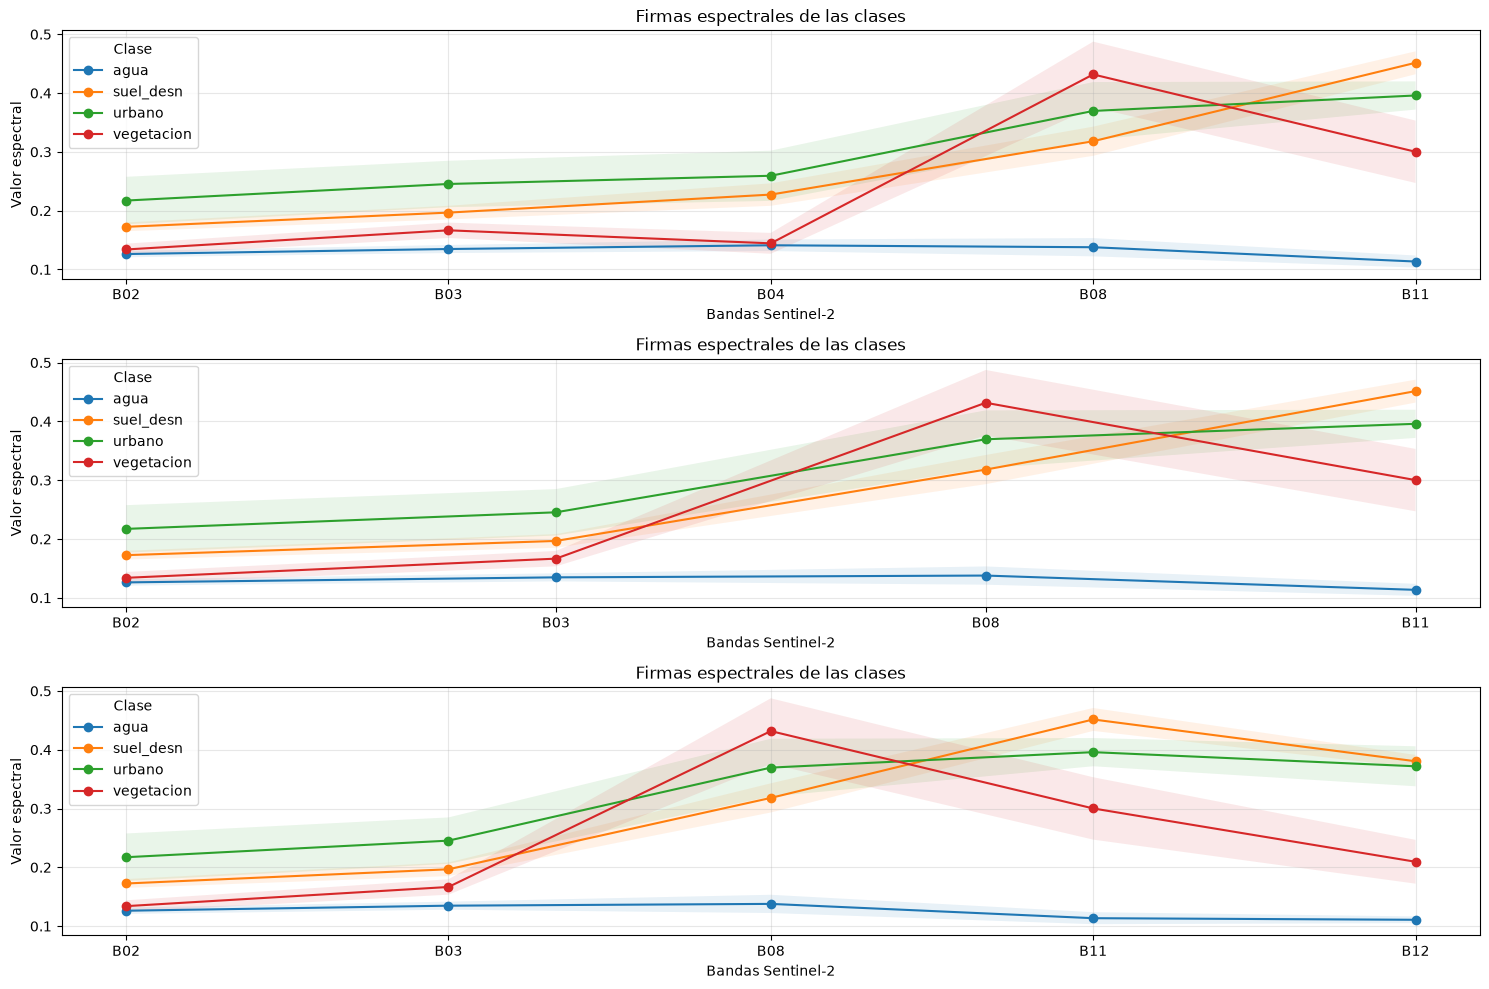

In [49]:
fig, ax = plt.subplots(3, 1, figsize=(15, 10), tight_layout=True)

for i, path in enumerate(list_outputs):

    muestras = pd.read_csv(list_outputs[i])
    muestras = muestras.drop(columns=['Unnamed: 0'])
    bandas = muestras.columns[:-1]
    
    for clase, grupo in muestras.groupby('Clase'):


        datos_clase = grupo[bandas] / 10000 # Dividimos por 10000 para que los valores queden expresados entre 0 y 1

        media_clase = datos_clase.mean(axis=0).to_numpy()
        std_clase = datos_clase.std(axis=0).to_numpy()

        ax[i].plot(bandas, media_clase, marker='o', label=clase)

        ax[i].fill_between(bandas, media_clase - std_clase, media_clase + std_clase, alpha=0.1)

    ax[i].set_xlabel('Bandas Sentinel-2')
    ax[i].set_ylabel('Valor espectral')
    ax[i].set_title('Firmas espectrales de las clases')

    #ax.set_xticks(longitudes_onda)
    #ax.set_xticklabels(['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2'])

    ax[i].legend(title='Clase')
    ax[i].grid(alpha=0.3)

plt.show()

<h3 style="color:red;">Ejercicio - Entregable!</h3>

Repetí la misma actividad del ejercicio anterior, pero esta vez leyendo el ráster que guardaste en la Clase 06 con un subconjunto de bandas menor (`output/S2_20181006_{bandas}_Clase06.tif`). Guarda el archivo CSV de muestras como `output/Muestras_Clase07_{bandas}`, donde `{bandas}` es el listado descriptivo de bandas que elegiste para armar ese ráster. Lo vas a utilizar en la Clase 07 para comparar cómo le fue a tu clasificador con este subconjunto de bandas.